In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc

from pybaselines import Baseline

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pybaselines")

from joblib import Parallel, delayed
from functools import partial

%matplotlib widget
plt.rcParams.update({'font.size': 16})

In [2]:
file = "CRAFTS_RA120_140_DEC-13_2.fits"
cube = sc.read(file).with_spectral_unit(u.km / u.s)

data = cube.unmasked_data[:, :, :].value
n_v = data.shape[0]
n_y = data.shape[1]
n_x = data.shape[2]

velocities = cube.spectral_axis.value
cube

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: km / s  range:     -599.897 km / s:     599.954 km / s

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (122.1875, -11.5625)>


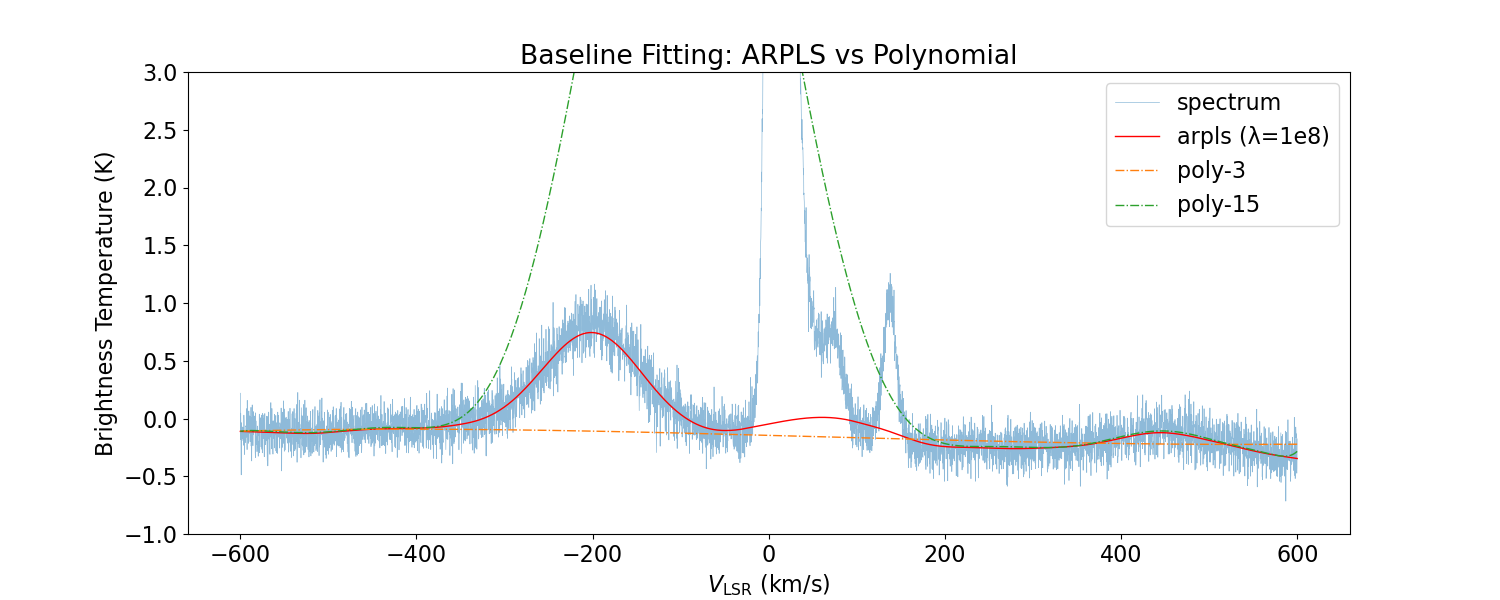

In [13]:
spectrum = data[:, 57, 712]
print(cube.wcs.celestial.pixel_to_world(712,57))

mask = (velocities < -350) | (velocities > 200)
v_masked = velocities[mask]
spec_masked = spectrum[mask]

# ARPLS method
bkg, params = Baseline(velocities).arpls(spectrum, lam=1e8)
# Create an array to hold the masked values in their original positions
#baseline_arpls = np.full_like(spectrum, np.nan, dtype=float)  # Initialize with NaN
#baseline_arpls[mask] = bkg  # Fill in the masked values at the correct positions

# Polynomial method
_, params = Baseline(v_masked).poly(spec_masked, poly_order=3, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly = np.polynomial.Polynomial(params['coef'])(velocities)

_, params2 = Baseline(v_masked).poly(spec_masked, poly_order=15, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly2 = np.polynomial.Polynomial(params2['coef'])(velocities)

fig = plt.figure(figsize=(15, 6))
plt.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
plt.plot(velocities, bkg, label='arpls (λ=1e8)', lw=1, color='red')
plt.plot(velocities, baseline_poly, '-.', label='poly-3', lw=1)
plt.plot(velocities, baseline_poly2, '-.', label='poly-15', lw=1)
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$', fontsize=16)
plt.ylabel('Brightness Temperature (K)', fontsize=16)
plt.ylim(-1, 3)
plt.title('Baseline Fitting: ARPLS vs Polynomial')
plt.savefig('baseline_fitting.png', dpi=300)
plt.show()

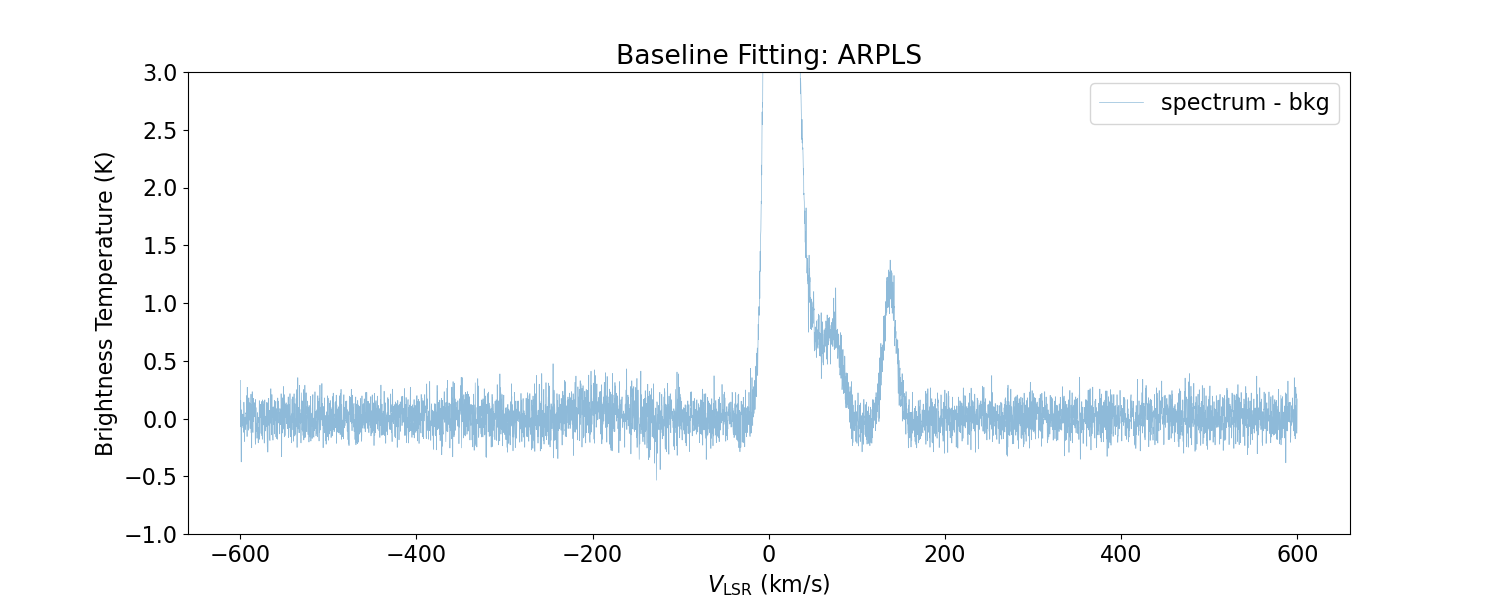

In [14]:
fig = plt.figure(figsize=(15, 6))
plt.plot(velocities, spectrum - bkg, label='spectrum - bkg', lw=0.5, alpha=0.5)
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$', fontsize=16)
plt.ylabel('Brightness Temperature (K)', fontsize=16)
plt.ylim(-1, 3)
plt.title('Baseline Fitting: ARPLS')
plt.savefig('baseline_fitting.png', dpi=300)

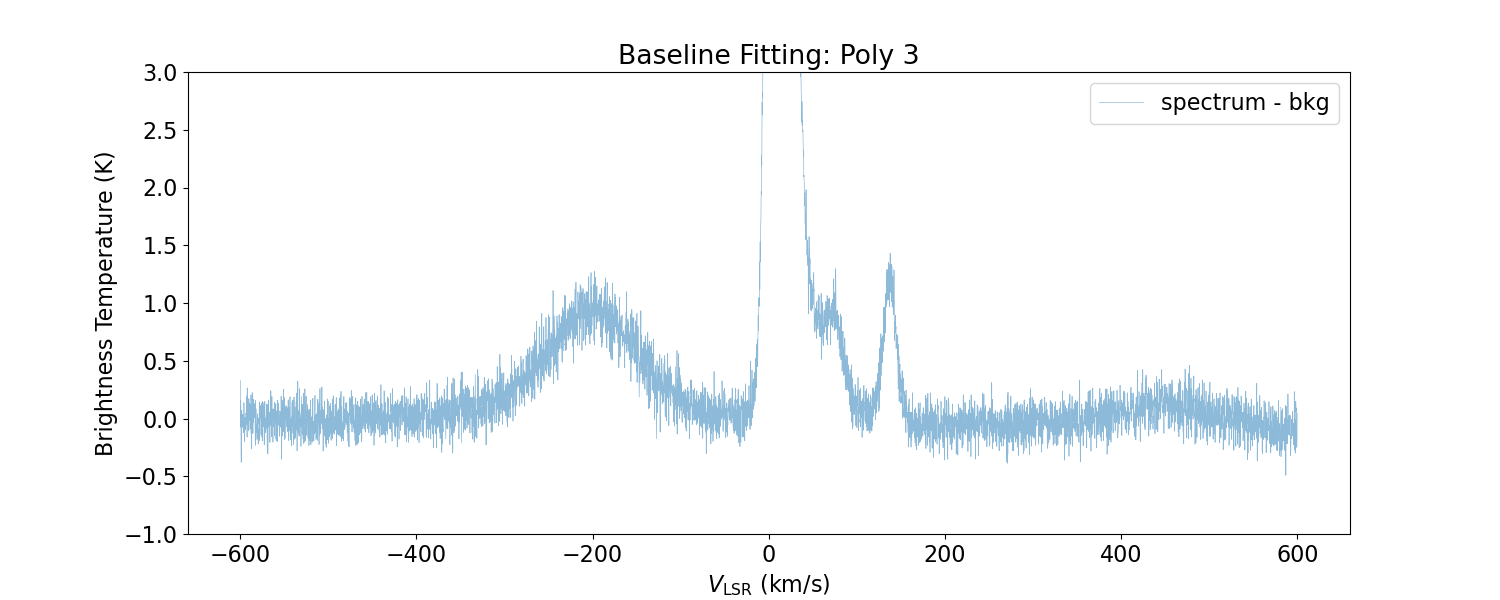

In [15]:
fig = plt.figure(figsize=(15, 6))
plt.plot(velocities, spectrum - baseline_poly, label='spectrum - bkg', lw=0.5, alpha=0.5)
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$', fontsize=16)
plt.ylabel('Brightness Temperature (K)', fontsize=16)
plt.ylim(-1, 3)
plt.title('Baseline Fitting: Poly 3')
plt.savefig('baseline_fitting.png', dpi=300)

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (130.1125, -7.1625)>


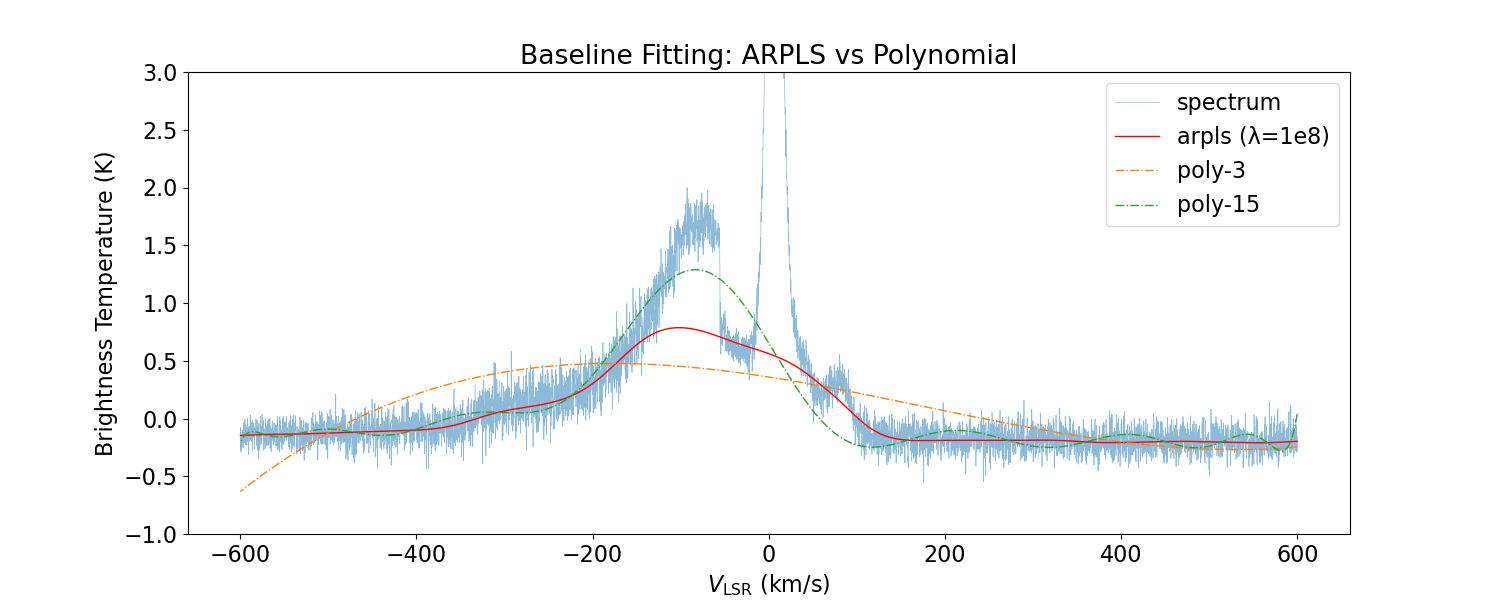

In [9]:
spectrum = data[:, 233, 395]
print(cube.wcs.celestial.pixel_to_world(395,233))

mask = (velocities < -20) | (velocities > 100)
v_masked = velocities[mask]
spec_masked = spectrum[mask]

# ARPLS method
bkg, params = Baseline(velocities).arpls(spectrum, lam=1e8)
# Create an array to hold the masked values in their original positions
#baseline_arpls = np.full_like(spectrum, np.nan, dtype=float)  # Initialize with NaN
#baseline_arpls[mask] = bkg  # Fill in the masked values at the correct positions

# Polynomial method
_, params = Baseline(v_masked).poly(spec_masked, poly_order=3, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly = np.polynomial.Polynomial(params['coef'])(velocities)

_, params2 = Baseline(v_masked).poly(spec_masked, poly_order=15, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly2 = np.polynomial.Polynomial(params2['coef'])(velocities)

fig = plt.figure(figsize=(15, 6))
plt.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
plt.plot(velocities, bkg, label='arpls (λ=1e8)', lw=1, color='red')
plt.plot(velocities, baseline_poly, '-.', label='poly-3', lw=1)
plt.plot(velocities, baseline_poly2, '-.', label='poly-15', lw=1)
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$', fontsize=16)
plt.ylabel('Brightness Temperature (K)', fontsize=16)
plt.ylim(-1, 3)
plt.title('Baseline Fitting: ARPLS vs Polynomial')
plt.savefig('baseline_fitting.png', dpi=300)
plt.show()

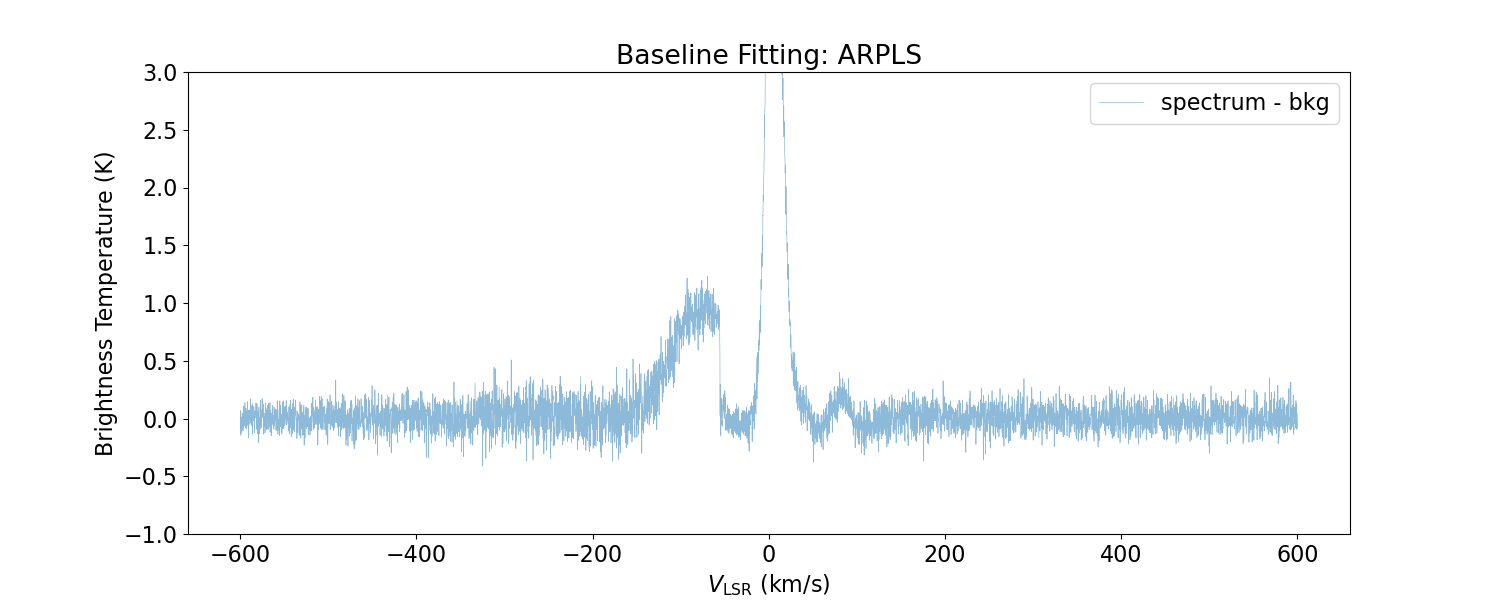

In [10]:
fig = plt.figure(figsize=(15, 6))
plt.plot(velocities, spectrum - bkg, label='spectrum - bkg', lw=0.5, alpha=0.5)
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$', fontsize=16)
plt.ylabel('Brightness Temperature (K)', fontsize=16)
plt.ylim(-1, 3)
plt.title('Baseline Fitting: ARPLS')
plt.savefig('baseline_fitting.png', dpi=300)